In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import geopandas as gpd
from glob import glob
import scipy.stats

In [2]:
eco_ts_objects = [
    xr.open_dataset(f) for f in
    glob("../data_working/eco_timeseries/*.nc")
]

s1_ts_objects = [
    xr.open_dataset(f) for f in
    glob("../data_working/s1_timeseries/*.nc")
]

In [3]:
eco_concat = pd.concat([obj.to_dataframe() for obj in eco_ts_objects])
s1_concat  = pd.concat([obj.to_dataframe() for obj in s1_ts_objects])

<Axes: ylabel='Frequency'>

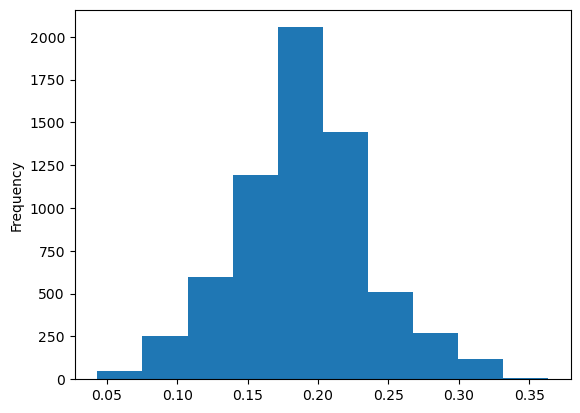

In [8]:
eco_concat[eco_concat.tmin == -1].groupby("sample").NDVI.var().pow(0.5).plot.hist()

<Axes: ylabel='Frequency'>

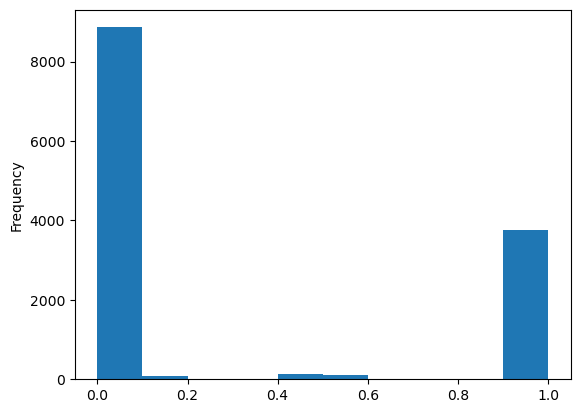

In [4]:
prop_s1_null_by_sample = s1_concat.isnull().groupby("sample")[["VV", "VH"]].mean()
prop_s1_null_by_sample["VV"].plot.hist()

In [5]:
# Different null proportions for each polarization indicates that
# reading failed partway through accessing all granules for a 
# geometry.
(prop_s1_null_by_sample["VV"] != prop_s1_null_by_sample["VH"]).value_counts()

False    13006
Name: count, dtype: int64

Apply growing season filter and attach severity

In [6]:
severity = pd.read_parquet("../data_working/detections.parquet", columns=["severity"])
severity.index.set_names(["geometry"], inplace=True)
growing_season = pd.read_parquet("../data_working/detections_phenology.parquet")
growing_season = growing_season.join(severity, how="inner")
growing_season.head()

,,lsp300_eosd_s1,lsp300_eosd_s2,lsp300_sosd_s1,lsp300_sosd_s2,lsp300_ampl_s1,lsp300_ampl_s2,lsp300_qa_s1,lsp300_qa_s2,severity
geometry,time,,,,,,,,,
0,2014-01-01,261.666656,NaN,112.333336,NaN,1862.000000,NaN,6.333333,255.0,0.000115
7263,2014-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
11259,2014-01-01,420.000000,NaN,107.000000,NaN,507.000000,NaN,76.000000,255.0,0.000000
12481,2014-01-01,243.000000,NaN,105.000000,NaN,1582.000000,NaN,1.000000,255.0,0.000000
0,2015-01-01,258.666656,NaN,118.666664,NaN,1851.666626,NaN,41.666668,255.0,0.000115


In [7]:
# Create temp year columns to allow imprecise date matching
growing_season["year"] = growing_season.index.get_level_values("time").year
eco_concat["year"] = eco_concat.index.get_level_values("time").year
s1_concat["year"] = s1_concat.index.get_level_values("time").year

In [8]:
# Rename sample index to match names
eco_concat.index = eco_concat.index.rename(dict(sample="geometry"))
s1_concat.index = s1_concat.index.rename(dict(sample="geometry"))

In [9]:
# Create temp obs date columns
eco_concat["obs_date"] = eco_concat.index.get_level_values("time")
eco_concat["obs_doy"] = eco_concat["obs_date"].dt.dayofyear

s1_concat["obs_date"] = s1_concat.index.get_level_values("time")
s1_concat["obs_doy"] = s1_concat["obs_date"].dt.dayofyear

In [10]:
# Drop time from index to allow merging
eco_concat = eco_concat.droplevel("time")
s1_concat = s1_concat.droplevel("time")

In [11]:
# Join growing sesaon
eco_join = pd.merge(
    eco_concat,
    growing_season,
    on=["geometry", "year"]
)

s1_join = pd.merge(
    s1_concat,
    growing_season,
    on=["geometry", "year"]
)

In [12]:
# Filter on growing season
eco_filter = eco_join[
    (eco_join["obs_doy"] >= eco_join["lsp300_sosd_s1"]) &
    (eco_join["obs_doy"] <= np.fmin(eco_join["lsp300_eosd_s1"], eco_join["lsp300_eosd_s2"]))
].copy()

s1_filter = s1_join[
    (s1_join["obs_doy"] >= s1_join["lsp300_sosd_s1"]) &
    (s1_join["obs_doy"] <= np.fmin(s1_join["lsp300_eosd_s1"], s1_join["lsp300_eosd_s2"]))
].copy()

<Axes: >

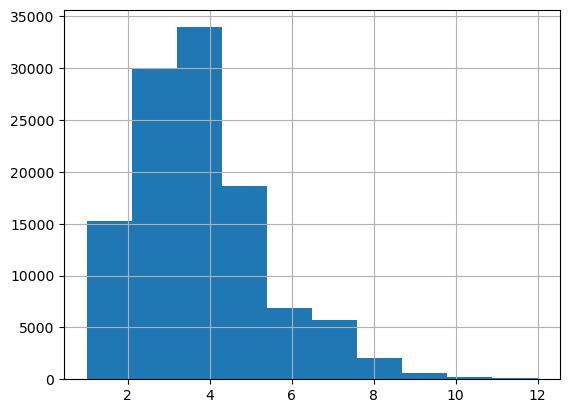

In [13]:
n_s1_obs_per_geom_year = s1_filter.groupby(["geometry", "year"]).size()
n_s1_obs_per_geom_year.hist()

<Axes: >

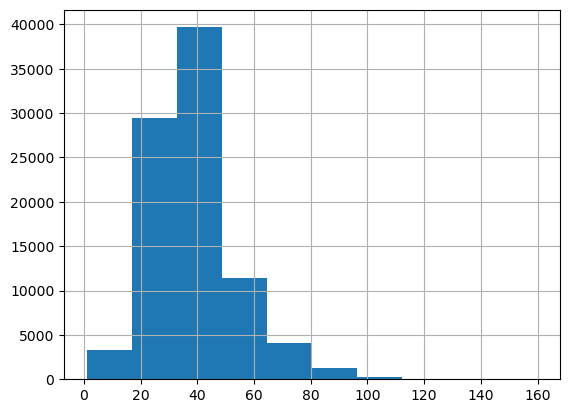

In [14]:
n_eco_obs_per_geom_year = eco_filter.groupby(["geometry", "year"]).size()
n_eco_obs_per_geom_year.hist()

In [28]:
geoms_with_mort = severity[severity["severity"] > 0].index

Ecostress: calculate thermal sensitivity before/after the mortality event

In [35]:
eco_filter["mort_phase"] = eco_filter["tmin"].case_when(caselist=[
    # Non-mortality patch
    (eco_filter["tmin"] == -1, "nonmort"),
    # Prior to event
    (eco_filter["year"] <  eco_filter["tmin"], "premort"),
    # After the event
    (eco_filter["year"] >  eco_filter["tmax"], "postmort"),
    # During the event
    (
        ((eco_filter["year"] >= eco_filter["tmin"]) &
        (eco_filter["year"] <= eco_filter["tmax"])),
        "mort"
    )
])

min_obs_per_phase = 10

eco_grouped_filter = eco_filter.groupby(["geometry", "mort_phase"])\
    .filter(lambda x: x["LST"].notna().sum() > min_obs_per_phase)

In [36]:
def robust_std(x: pd.Series):
    '''
    Standardize `x` as (x - median(x)) / IQR.
    '''
    return (x - x.median()) / (x.quantile(0.75) - x.quantile(0.25))

def tetens_eqn(ta: np.array):
    '''
    Calculate saturation vapor pressure (kPa) from air temperature (deg C).

    From https://en.wikipedia.org/wiki/Tetens_equation
    '''
    return 0.61078 * np.exp((17.27 * ta) / (ta + 237.3))

eco_grouped_filter["deltaT"]     = eco_grouped_filter["LST"] - eco_grouped_filter["Ta"]
eco_grouped_filter["VPD"]        = tetens_eqn(eco_grouped_filter["Ta"]) * (1 - eco_grouped_filter["RH"])

to_standardize = ["deltaT", "LST", "Ta", "VPD", "NDVI", "ESI", "PET"]

for var in to_standardize:
    eco_grouped_filter[var+"_std"] = eco_grouped_filter.groupby('geometry')[var].transform(robust_std)

In [37]:
def theilsen(x, y):
    return scipy.stats.theilslopes(y, x, nan_policy="omit").slope

In [38]:
# silence small sample warnings from theilsen
import warnings
warnings.filterwarnings("ignore", message=".*sample arguments is too small.*")

In [39]:
# Annual mean of standardized variables, and annual sensitivity of deltaT_std to
# vapor pressure deficit
def aggregation_driver(x: pd.DataFrame, mean_cols: list[str]=["deltaT_std", "LST_std", "NDVI_std", "ESI_std", "PET_std"]):
    # Mean of standardized variables
    ret = pd.Series({
        v: x[v].mean()
        for v in mean_cols
    })

    # Sensitivity of deltaT to VPD
    sens = theilsen(x["VPD"], x["deltaT_std"])

    ret.loc["vpd_sens"] = sens
    return ret

eco_grouped_filter["year_rel"] = eco_grouped_filter["year"] - eco_grouped_filter["tmin"]
eco_with_mort_ann_summary = eco_grouped_filter[eco_grouped_filter["tmin"] != -1]\
    .groupby(["geometry"])\
    .filter(lambda x: x["year_rel"].max() < 6)\
    .groupby(["geometry", "year_rel"]).apply(aggregation_driver)

/tmp/ipykernel_8951/1092570850.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .groupby(["geometry", "year_rel"]).apply(aggregation_driver)


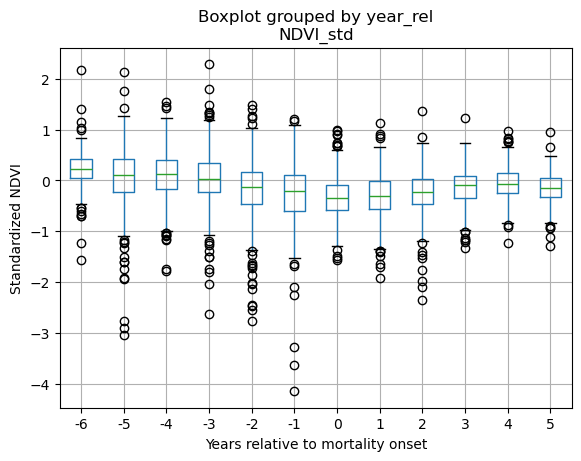

In [41]:
from matplotlib import pyplot as plt

eco_with_mort_ann_summary.reset_index().boxplot(by="year_rel", column="NDVI_std")
plt.xlabel("Years relative to mortality onset")
plt.ylabel("Standardized NDVI")
plt.show()

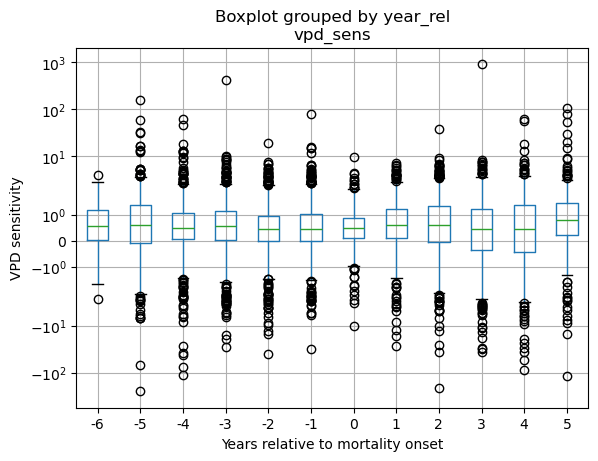

In [43]:
eco_with_mort_ann_summary.reset_index().boxplot(by="year_rel", column="vpd_sens")
plt.xlabel("Years relative to mortality onset")
plt.ylabel("VPD sensitivity")
plt.yscale("symlog")
plt.show()

In [44]:
ann_ndvi_pivot = eco_with_mort_ann_summary["NDVI_std"].reset_index().pivot(index="geometry", columns="year_rel")

In [45]:
ttest_result = scipy.stats.ttest_1samp(ann_ndvi_pivot, 0, nan_policy="omit", alternative="less")

In [46]:
for col, pv in zip(ann_ndvi_pivot.columns, ttest_result.pvalue):
    print(col, pv*ann_ndvi_pivot.shape[1])

('NDVI_std', -6) 11.999999986673558
('NDVI_std', -5) 11.228421807590264
('NDVI_std', -4) 11.99999947405918
('NDVI_std', -3) 11.985887956283083
('NDVI_std', -2) 2.662008216618669e-13
('NDVI_std', -1) 1.3365969833205867e-28
('NDVI_std', 0) 4.933557120155789e-31
('NDVI_std', 1) 2.4249828688952763e-53
('NDVI_std', 2) 6.49003721055173e-36
('NDVI_std', 3) 2.701062581563804e-13
('NDVI_std', 4) 0.002460850836495824
('NDVI_std', 5) 6.677308719071551e-10


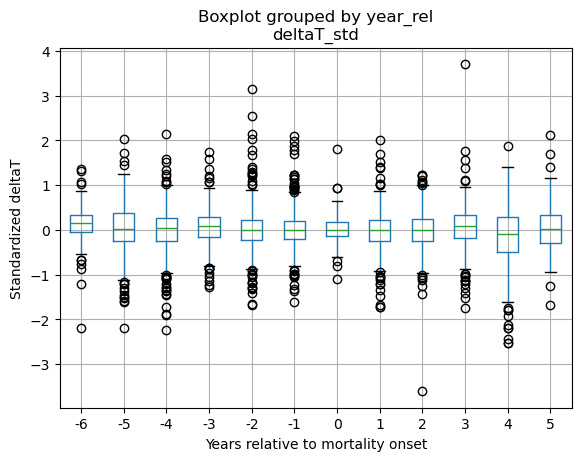

In [47]:
eco_with_mort_ann_summary.reset_index().boxplot(by="year_rel", column="deltaT_std")
plt.xlabel("Years relative to mortality onset")
plt.ylabel("Standardized deltaT")
plt.show()

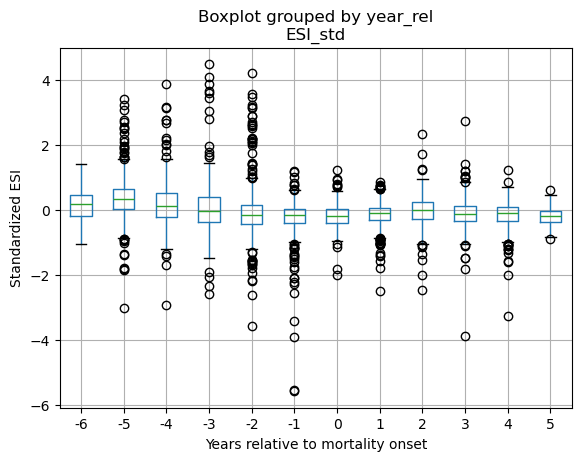

In [48]:
eco_with_mort_ann_summary.reset_index().boxplot(by="year_rel", column="ESI_std")
plt.xlabel("Years relative to mortality onset")
plt.ylabel("Standardized ESI")
plt.show()

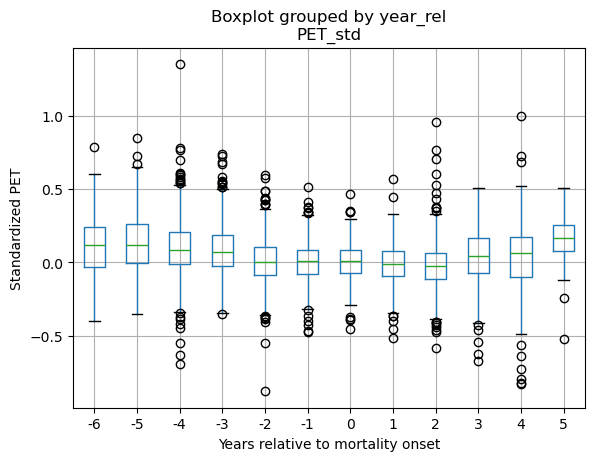

In [49]:
eco_with_mort_ann_summary.reset_index().boxplot(by="year_rel", column="PET_std")
plt.xlabel("Years relative to mortality onset")
plt.ylabel("Standardized PET")
plt.show()

Plot growing season NDVI for events where we have plenty of ECOSTRESS data

In [50]:
mort_events_21 = eco_grouped_filter[eco_grouped_filter.tmin == 2021]

In [51]:
group_sample = mort_events_21.index.get_level_values("geometry").unique()
max_mort = mort_events_21["severity"].idxmax()

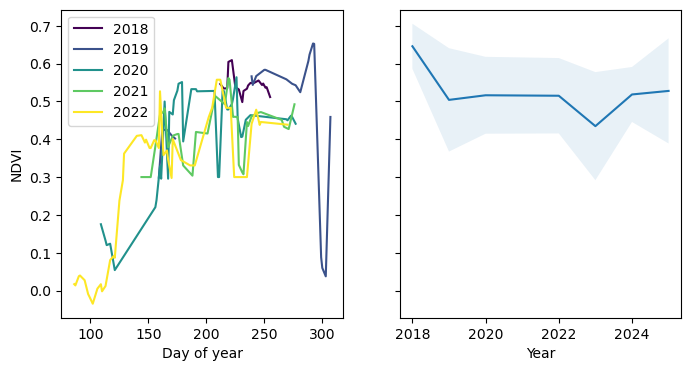

In [58]:
import matplotlib.cm as cm

fig, ax = plt.subplots(1, 2, sharey=True, figsize=(8, 4))

geom = group_sample[100] # arbitrary index, or use max_mort
n_years = mort_events_21.loc[max_mort]["year"].value_counts().size

colors = cm.viridis(np.linspace(0, 1, n_years))

for i, (year, data) in enumerate(mort_events_21.loc[max_mort].groupby("year")):
    ax[0].plot(data["obs_doy"], data["NDVI"], color=colors[i], label=year)

ann_mean = mort_events_21.loc[geom].groupby("year")["NDVI"].mean()
ann_std  = mort_events_21.loc[geom].groupby("year")["NDVI"].std()

ax[1].fill_between(ann_std.index, ann_mean-ann_std, ann_mean+ann_std, alpha=0.1)
ann_mean.plot(ax=ax[1])

ax[0].set_xlabel("Day of year")
ax[0].set_ylabel("NDVI")
ax[0].legend()

ax[1].set_xlabel("Year")

plt.show()

Sentinel-1: do we see changes in backscatter relative to mortality?

In [67]:
# Convert backscatter to db
s1_nan_filter = s1_filter[(~s1_filter[["VV", "VH"]].isnull()).all(axis=1)].copy()
s1_nan_filter["VV_db"] = 10 * np.log10(s1_nan_filter["VV"])
s1_nan_filter["VH_db"] = 10 * np.log10(s1_nan_filter["VH"])

# Standardize
warnings.filterwarnings("ignore", message=".*Mean of empty slice.*")
for feature in ["VV_db", "VH_db"]:
    s1_nan_filter[feature+"_std"] = s1_nan_filter.groupby('geometry')[feature].transform(robust_std)

/srv/conda/envs/notebook/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [68]:
# Annual mean
s1_nan_filter["year_rel"] = s1_nan_filter["year"] - s1_nan_filter["tmin"]
s1_with_mort_ann_summary = s1_nan_filter[s1_nan_filter["tmin"] != -1]\
    .groupby(["geometry"])\
    .filter(lambda x: x["year_rel"].max() < 6)\
    .groupby(["geometry", "year_rel"])\
    .agg({"VV_db_std": "mean", "VH_db_std": "mean"})

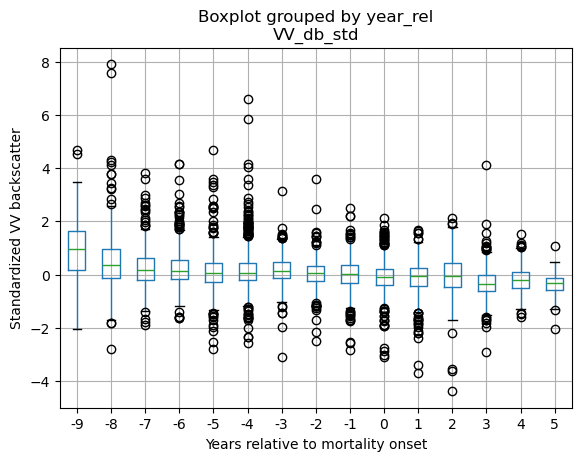

In [69]:
s1_with_mort_ann_summary.reset_index().boxplot(by="year_rel", column="VV_db_std")
plt.xlabel("Years relative to mortality onset")
plt.ylabel("Standardized VV backscatter")
plt.show()

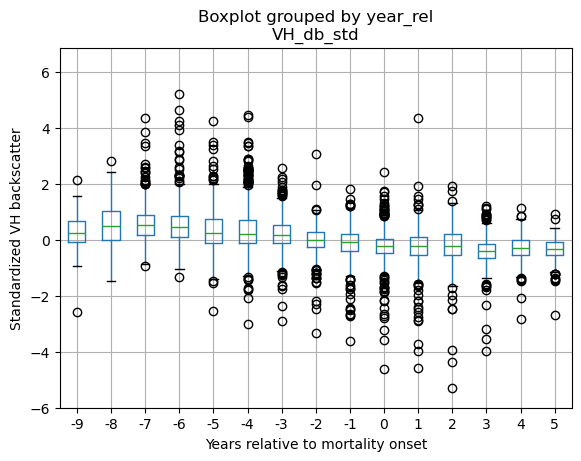

In [72]:
s1_with_mort_ann_summary.reset_index().boxplot(by="year_rel", column="VH_db_std")
plt.ylim(-6, None)
plt.xlabel("Years relative to mortality onset")
plt.ylabel("Standardized VH backscatter")
plt.show()